In [ ]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

In [ ]:
#Source: https://data.vta.org/datasets/VTA::vta-stops-and-routes-october-2025/explore?layer=1
routes_gdf = gpd.read_file('../data/raw/Routes_October_2025.geojson')
routes_gdf = routes_gdf.to_crs("EPSG:2227")

selected_routes = ['22', '522', '23', '523', '25', '60']

#select routes 22, 522, 23, 523, 25, and 60
selected_routes_gdf = routes_gdf[routes_gdf['lineabbr'].isin(selected_routes)]
selected_routes_gdf = selected_routes_gdf.rename(columns={
    'lineid' : 'route_id',
    'lineabbr' : 'route_name',
    'linename' : 'route_desc',
    'SHAPE__Length' : 'route_length',
    'objectid' : 'object_id'
    })

selected_routes_gdf

,route_id,route_name,route_desc,category,route_length,object_id,geometry
2,23875,22,PALO ALTO - EASTRIDGE,Frequent,242559.907697,3,"MULTILINESTRING ((6078120.21 1988261.911, 6078..."
3,23876,23,DE ANZA COL - ALUM ROCK STN,Frequent,120202.952188,4,"MULTILINESTRING ((6158970.5 1948773.359, 61591..."
4,23879,25,DE ANZA COL - VMC - ALUM ROCK STN,Frequent,140850.289491,5,"MULTILINESTRING ((6159010.974 1938537.442, 615..."
20,23904,60,WINCHESTER STN - MILPITAS BART,Frequent,151256.059019,21,"MULTILINESTRING ((6140271.837 1927485.307, 614..."
54,23896,522,PALO ALTO - EASTRIDGE,Rapid,253522.042435,55,"MULTILINESTRING ((6078120.21 1988261.911, 6078..."
55,23897,523,SAN JOSE STATE - LOCKHEED MARTIN,Rapid,162676.690292,56,"MULTILINESTRING ((6117718.556 1975678.574, 611..."


In [10]:
selected_routes_gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 6 entries, 2 to 55
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   route_id      6 non-null      int32   
 1   route_name    6 non-null      object  
 2   route_desc    6 non-null      object  
 3   category      6 non-null      object  
 4   route_length  6 non-null      float64 
 5   object_id     6 non-null      int32   
 6   geometry      6 non-null      geometry
dtypes: float64(1), geometry(1), int32(2), object(3)
memory usage: 336.0+ bytes


<Axes: >

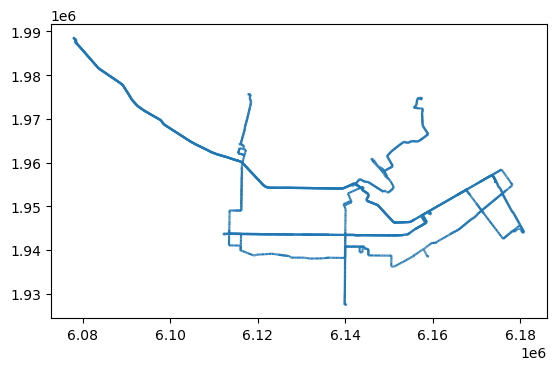

In [11]:
selected_routes_gdf.plot()

In [ ]:
#Source: https://data.vta.org/datasets/VTA::vta-stops-and-routes-october-2025/about?layer=0
stations_df = pd.read_csv("../data/raw/Bus_LightRail_Stops.csv")
stations_df

,X,Y,routes,linedirid,rtid,stopname,objectid
0,6.144100e+06,1.954226e+06,22,238750,60001,Santa Clara Transit Center,1
1,6.146822e+06,1.959781e+06,"60, 60",239040,60008,San Jose Airport Terminal A,2
2,6.148115e+06,1.958315e+06,60,239041,60011,San Jose Airport Terminal B,3
3,6.150233e+06,1.960219e+06,60,239041,60014,1st & Metro @ Metro Station,4
4,6.141651e+06,1.954992e+06,"22, 59, 60",238750,60020,El Camino & Lafayette,5
...,...,...,...,...,...,...,...
3245,6.140506e+06,1.930527e+06,26,238821,66063,Civic Center & 3rd,3246
3246,6.157411e+06,1.941970e+06,201,238710,66066,Virginia & Virginia Station,3247
3247,6.146206e+06,1.935440e+06,202,238720,66067,Stokes & Southwest Expressway,3248
3248,6.190774e+06,1.935478e+06,"31, 39",238870,66068,San Felipe & Bowery,3249


In [ ]:
#Source: https://data.vta.org/pages/f2ebbac0b3a84c5e958ca45a4676f282
ridership_df = pd.read_excel("../data/raw/October_2025_Ridership_by_Stop.xlsx")
ridership_df = ridership_df.rename(columns={"Stop_ID_Num": "rtid"})
ridership_df

,rtid,SERVICE_PERIOD,MAIN_CROSS_STREET,ROUTES_SERVED,AVG_BOARDINGS,AVG_ALIGHTINGS,AVG_ACTIVITY
0,60001,Weekday,SANTA CLARA TRANSIT CENTER,22,152.880022,110.852250,263.732272
1,60008,Weekday,SAN JOSE AIRPORT - TERMINAL A,60,106.410278,97.183657,203.593936
2,60011,Weekday,SAN JOSE AIRPORT - TERMINAL B,60,101.895229,69.917892,171.813122
3,60014,Weekday,1ST + METRO,60,99.060686,57.995466,157.056152
4,60020,Weekday,EL CAMINO + LAFAYETTE,"22, 59, 60",40.890986,57.438087,98.329073
...,...,...,...,...,...,...,...
3113,66063,Weekday,CIVIC CENTER + 3RD,26,3.281537,14.682573,17.964110
3114,66066,Weekday,VIRGINIA + VIRGINIA STATION,201,0.333333,0.000000,0.333333
3115,66067,Weekday,STOKES + SOUTHWEST EXPWY,202,0.000000,0.357143,0.357143
3116,66068,Weekday,SAN FELIPE + BOWERY,"31, 39",1.279642,0.336508,1.616150


In [14]:
station_ridership_df = pd.merge(stations_df, ridership_df, on='rtid', how='left')
station_ridership_df

,X,Y,routes,linedirid,rtid,stopname,objectid,SERVICE_PERIOD,MAIN_CROSS_STREET,ROUTES_SERVED,AVG_BOARDINGS,AVG_ALIGHTINGS,AVG_ACTIVITY
0,6.144100e+06,1.954226e+06,22,238750,60001,Santa Clara Transit Center,1,Weekday,SANTA CLARA TRANSIT CENTER,22,152.880022,110.852250,263.732272
1,6.146822e+06,1.959781e+06,"60, 60",239040,60008,San Jose Airport Terminal A,2,Weekday,SAN JOSE AIRPORT - TERMINAL A,60,106.410278,97.183657,203.593936
2,6.148115e+06,1.958315e+06,60,239041,60011,San Jose Airport Terminal B,3,Weekday,SAN JOSE AIRPORT - TERMINAL B,60,101.895229,69.917892,171.813122
3,6.150233e+06,1.960219e+06,60,239041,60014,1st & Metro @ Metro Station,4,Weekday,1ST + METRO,60,99.060686,57.995466,157.056152
4,6.141651e+06,1.954992e+06,"22, 59, 60",238750,60020,El Camino & Lafayette,5,Weekday,EL CAMINO + LAFAYETTE,"22, 59, 60",40.890986,57.438087,98.329073
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3245,6.140506e+06,1.930527e+06,26,238821,66063,Civic Center & 3rd,3246,Weekday,CIVIC CENTER + 3RD,26,3.281537,14.682573,17.964110
3246,6.157411e+06,1.941970e+06,201,238710,66066,Virginia & Virginia Station,3247,Weekday,VIRGINIA + VIRGINIA STATION,201,0.333333,0.000000,0.333333
3247,6.146206e+06,1.935440e+06,202,238720,66067,Stokes & Southwest Expressway,3248,Weekday,STOKES + SOUTHWEST EXPWY,202,0.000000,0.357143,0.357143
3248,6.190774e+06,1.935478e+06,"31, 39",238870,66068,San Felipe & Bowery,3249,Weekday,SAN FELIPE + BOWERY,"31, 39",1.279642,0.336508,1.616150


In [15]:
#set routes data type to str only and if 2 routes share a station, give each its own row for easier filtering later
station_ridership_df["routes"] = station_ridership_df["routes"].str.split(", ")
station_ridership_df = station_ridership_df.explode("routes")
station_ridership_df = station_ridership_df.drop_duplicates()

station_ridership_gdf_geometry = [Point(xy) for xy in zip(station_ridership_df["X"], station_ridership_df["Y"])]

station_ridership_gdf = gpd.GeoDataFrame(station_ridership_df, geometry=station_ridership_gdf_geometry, crs="EPSG:2227")
station_ridership_gdf

,X,Y,routes,linedirid,rtid,stopname,objectid,SERVICE_PERIOD,MAIN_CROSS_STREET,ROUTES_SERVED,AVG_BOARDINGS,AVG_ALIGHTINGS,AVG_ACTIVITY,geometry
0,6.144100e+06,1.954226e+06,22,238750,60001,Santa Clara Transit Center,1,Weekday,SANTA CLARA TRANSIT CENTER,22,152.880022,110.852250,263.732272,POINT (6144099.628 1954225.52)
1,6.146822e+06,1.959781e+06,60,239040,60008,San Jose Airport Terminal A,2,Weekday,SAN JOSE AIRPORT - TERMINAL A,60,106.410278,97.183657,203.593936,POINT (6146822.451 1959780.783)
2,6.148115e+06,1.958315e+06,60,239041,60011,San Jose Airport Terminal B,3,Weekday,SAN JOSE AIRPORT - TERMINAL B,60,101.895229,69.917892,171.813122,POINT (6148114.706 1958314.711)
3,6.150233e+06,1.960219e+06,60,239041,60014,1st & Metro @ Metro Station,4,Weekday,1ST + METRO,60,99.060686,57.995466,157.056152,POINT (6150233.012 1960218.742)
4,6.141651e+06,1.954992e+06,22,238750,60020,El Camino & Lafayette,5,Weekday,EL CAMINO + LAFAYETTE,"22, 59, 60",40.890986,57.438087,98.329073,POINT (6141651.003 1954992.246)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3246,6.157411e+06,1.941970e+06,201,238710,66066,Virginia & Virginia Station,3247,Weekday,VIRGINIA + VIRGINIA STATION,201,0.333333,0.000000,0.333333,POINT (6157411.327 1941969.795)
3247,6.146206e+06,1.935440e+06,202,238720,66067,Stokes & Southwest Expressway,3248,Weekday,STOKES + SOUTHWEST EXPWY,202,0.000000,0.357143,0.357143,POINT (6146206.479 1935440.473)
3248,6.190774e+06,1.935478e+06,31,238870,66068,San Felipe & Bowery,3249,Weekday,SAN FELIPE + BOWERY,"31, 39",1.279642,0.336508,1.616150,POINT (6190773.704 1935477.602)
3248,6.190774e+06,1.935478e+06,39,238870,66068,San Felipe & Bowery,3249,Weekday,SAN FELIPE + BOWERY,"31, 39",1.279642,0.336508,1.616150,POINT (6190773.704 1935477.602)


In [16]:
#remove unnecessary columns
cols = [
    "routes",
    "linedirid",
    "rtid", 
    "stopname", 
    "AVG_BOARDINGS", 
    "AVG_ALIGHTINGS",
    "AVG_ACTIVITY",
    "geometry"
]

ridership_gdf = station_ridership_gdf[cols].copy()

ridership_gdf = ridership_gdf.rename(columns={
    "routes": "route_name",
    "linedirid": "route_direction_id",
    "rtid": "stop_id",
    "stopname": "stop_name",
    "AVG_BOARDINGS": "boardings",
    "AVG_ALIGHTINGS": "alightings",
    "AVG_ACTIVITY": "total_b_a"
})

ridership_gdf

,route_name,route_direction_id,stop_id,stop_name,boardings,alightings,total_b_a,geometry
0,22,238750,60001,Santa Clara Transit Center,152.880022,110.852250,263.732272,POINT (6144099.628 1954225.52)
1,60,239040,60008,San Jose Airport Terminal A,106.410278,97.183657,203.593936,POINT (6146822.451 1959780.783)
2,60,239041,60011,San Jose Airport Terminal B,101.895229,69.917892,171.813122,POINT (6148114.706 1958314.711)
3,60,239041,60014,1st & Metro @ Metro Station,99.060686,57.995466,157.056152,POINT (6150233.012 1960218.742)
4,22,238750,60020,El Camino & Lafayette,40.890986,57.438087,98.329073,POINT (6141651.003 1954992.246)
...,...,...,...,...,...,...,...,...
3246,201,238710,66066,Virginia & Virginia Station,0.333333,0.000000,0.333333,POINT (6157411.327 1941969.795)
3247,202,238720,66067,Stokes & Southwest Expressway,0.000000,0.357143,0.357143,POINT (6146206.479 1935440.473)
3248,31,238870,66068,San Felipe & Bowery,1.279642,0.336508,1.616150,POINT (6190773.704 1935477.602)
3248,39,238870,66068,San Felipe & Bowery,1.279642,0.336508,1.616150,POINT (6190773.704 1935477.602)


In [17]:
#select routes 22, 522, 23, 523, 25, and 60
selected_ridership_gdf = ridership_gdf[ridership_gdf['route_name'].isin(selected_routes)]
selected_ridership_gdf

,route_name,route_direction_id,stop_id,stop_name,boardings,alightings,total_b_a,geometry
0,22,238750,60001,Santa Clara Transit Center,152.880022,110.852250,263.732272,POINT (6144099.628 1954225.52)
1,60,239040,60008,San Jose Airport Terminal A,106.410278,97.183657,203.593936,POINT (6146822.451 1959780.783)
2,60,239041,60011,San Jose Airport Terminal B,101.895229,69.917892,171.813122,POINT (6148114.706 1958314.711)
3,60,239041,60014,1st & Metro @ Metro Station,99.060686,57.995466,157.056152,POINT (6150233.012 1960218.742)
4,22,238750,60020,El Camino & Lafayette,40.890986,57.438087,98.329073,POINT (6141651.003 1954992.246)
...,...,...,...,...,...,...,...,...
3219,23,238761,66001,San Carlos & Meridian,156.296391,174.049290,330.345680,POINT (6150710.015 1943405.861)
3219,523,238761,66001,San Carlos & Meridian,156.296391,174.049290,330.345680,POINT (6150710.015 1943405.861)
3221,60,239040,66019,San Jose Airport Terminal B,105.515644,69.771954,175.287597,POINT (6148161.172 1958273.948)
3225,25,238790,66033,Clove & Ginger,37.628251,52.159478,89.787729,POINT (6143691.14 1939440.166)


<Axes: >

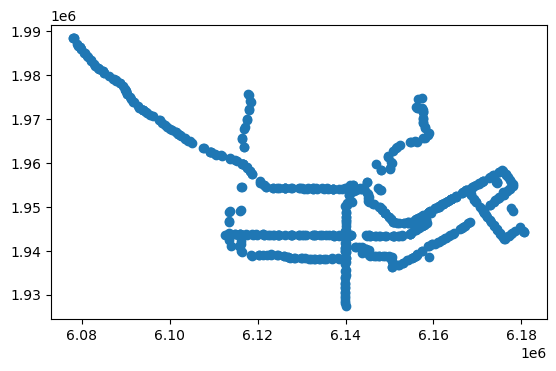

In [18]:
selected_ridership_gdf.plot()

In [ ]:
#save in separate folder
selected_routes_gdf.to_csv('../data/processed/selected_routes.csv')
selected_ridership_gdf.to_csv('../data/processed/selected_station_ridership.csv')

In [ ]:
#Source: https://gisdata-csj.opendata.arcgis.com/datasets/CSJ::average-daily-traffic/explore?location=37.332044%2C-121.880204%2C10
adt_df = pd.read_csv('../data/raw/Average_Daily_Traffic.csv')
adt_gdf_geometry = [Point(xy) for xy in zip(adt_df["X"], adt_df["Y"])]

adt_gdf = gpd.GeoDataFrame(adt_df, geometry=adt_gdf_geometry, crs="EPSG:2227")
adt_gdf = adt_gdf.to_crs("EPSG:2227")
adt_gdf

,X,Y,OBJECTID,FACILITYID,INTID,LATITUDE,LONGITUDE,COUNTDATE,ADT,STREETONE,...,STREETTWO,TRAVELDIRE,NEARINTERS,CITY,ADTONE,ADTTWO,CREATIONDATE,LASTUPDATE,NOTES,geometry
0,6.159659e+06,1.952402e+06,4446,2045,2045,37.348694,-121.883045,2018/03/27 00:00:00+00,5613.0,13TH ST,...,WASHINGTON ST,N/S,13TH ST & WASHINGTON ST,San Jose,2339.0,3274.0,NaN,2021/03/18 17:05:47+00,,POINT (6159659.425 1952401.843)
1,6.165294e+06,1.938841e+06,4447,2046,2046,37.311681,-121.862988,2018/04/10 00:00:00+00,6265.0,7TH ST,...,LEO AVE,N/S,7TH ST & LEO AVE,San Jose,2842.0,3423.0,NaN,2021/03/18 17:05:47+00,,POINT (6165293.598 1938841.482)
2,6.158495e+06,1.951732e+06,4448,2047,2047,37.346808,-121.887016,2018/07/31 00:00:00+00,1043.0,9TH ST,...,WASHINGTON ST,N/S,9TH ST & WASHINGTON ST,San Jose,589.0,454.0,NaN,2021/03/18 17:05:47+00,,POINT (6158494.955 1951732.473)
3,6.158545e+06,1.951646e+06,4449,2048,2048,37.346572,-121.886841,2018/07/31 00:00:00+00,1207.0,9TH ST,...,WASHINGTON ST,N/S,9TH ST & WASHINGTON ST,San Jose,740.0,467.0,NaN,2021/03/18 17:05:47+00,,POINT (6158544.746 1951645.735)
4,6.148940e+06,1.958002e+06,4450,2049,2049,37.363632,-121.920211,2018/08/22 00:00:00+00,14432.0,AIRPORT BLVD,...,SKYPORT DR,One Way,AIRPORT BLVD & SKYPORT DR,San Jose,NaN,NaN,NaN,2021/03/18 17:05:47+00,,POINT (6148939.759 1958001.956)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2394,6.169466e+06,1.956389e+06,7281,4473,4473,37.360029,-121.849505,2021/12/02 00:00:00+00,3994.0,Jose Figueres Ave,...,Rio Guacimal Ct,N/S,Jose Figueres Ave & Rio Guacimal Ct,San Jose,1983.0,2011.0,NaN,2022/04/14 20:14:37+00,NaN,POINT (6169465.578 1956389.19)
2395,6.171081e+06,1.954917e+06,7282,4474,4474,37.356051,-121.843873,2021/12/02 00:00:00+00,1207.0,Scharff Ave,...,Lausett Ave,N/S,Scharff Ave & Lausett Ave,San Jose,656.0,551.0,NaN,2022/04/14 20:14:37+00,NaN,POINT (6171081.379 1954917.494)
2396,6.164263e+06,1.950131e+06,7283,4475,4475,37.342634,-121.867090,2021/12/02 00:00:00+00,3068.0,San Antonio St,...,21st St,E/W,San Antonio St & 21st St,San Jose,1521.0,1547.0,NaN,2022/04/14 20:14:37+00,NaN,POINT (6164262.808 1950130.677)
2397,6.164839e+06,1.950568e+06,7284,4476,4476,37.343858,-121.865132,2021/12/02 00:00:00+00,4238.0,San Antonio St,...,23rd St,E/W,San Antonio St & 23rd St,San Jose,2305.0,1933.0,NaN,2022/04/14 20:14:37+00,NaN,POINT (6164838.516 1950567.683)


In [21]:
cols = [
    "OBJECTID",
    "ADT",
    "STREETONE", 
    "DIRECTION", 
    "STREETTWO", 
    "NEARINTERS",
    "geometry"
]

sj_adt_gdf = adt_gdf[cols].copy()

sj_adt_gdf = sj_adt_gdf.rename(columns={
    "OBJECTID" : "counter_id",
    "ADT" : "adt",
    "STREETONE" : "main_road", 
    "DIRECTION" : "counter_location", 
    "STREETTWO" : "cross_road", 
    "NEARINTERS" : "nearby_intersect"
})

sj_adt_gdf.dropna()
sj_adt_gdf['main_road'] = [item.upper() for item in sj_adt_gdf['main_road']]
sj_adt_gdf['cross_road'] = [item.upper() for item in sj_adt_gdf['cross_road']]
sj_adt_gdf['nearby_intersect'] = [item.upper() for item in sj_adt_gdf['nearby_intersect']]
sj_adt_gdf

,counter_id,adt,main_road,counter_location,cross_road,nearby_intersect,geometry
0,4446,5613.0,13TH ST,N of,WASHINGTON ST,13TH ST & WASHINGTON ST,POINT (6159659.425 1952401.843)
1,4447,6265.0,7TH ST,S of,LEO AVE,7TH ST & LEO AVE,POINT (6165293.598 1938841.482)
2,4448,1043.0,9TH ST,N of,WASHINGTON ST,9TH ST & WASHINGTON ST,POINT (6158494.955 1951732.473)
3,4449,1207.0,9TH ST,S of,WASHINGTON ST,9TH ST & WASHINGTON ST,POINT (6158544.746 1951645.735)
4,4450,14432.0,AIRPORT BLVD,S of,SKYPORT DR,AIRPORT BLVD & SKYPORT DR,POINT (6148939.759 1958001.956)
...,...,...,...,...,...,...,...
2394,7281,3994.0,JOSE FIGUERES AVE,S of,RIO GUACIMAL CT,JOSE FIGUERES AVE & RIO GUACIMAL CT,POINT (6169465.578 1956389.19)
2395,7282,1207.0,SCHARFF AVE,N of,LAUSETT AVE,SCHARFF AVE & LAUSETT AVE,POINT (6171081.379 1954917.494)
2396,7283,3068.0,SAN ANTONIO ST,E of,21ST ST,SAN ANTONIO ST & 21ST ST,POINT (6164262.808 1950130.677)
2397,7284,4238.0,SAN ANTONIO ST,E of,23RD ST,SAN ANTONIO ST & 23RD ST,POINT (6164838.516 1950567.683)


In [22]:
#create a buffer around the selected routes, then select all traffic counters within the buffer
route_buffers = selected_routes_gdf.copy()
route_buffers['geometry'] = route_buffers['geometry'].buffer(250)
route_buffers

,route_id,route_name,route_desc,category,route_length,object_id,geometry
2,23875,22,PALO ALTO - EASTRIDGE,Frequent,242559.907697,3,"POLYGON ((6077535.047 1988551.009, 6077535.02 ..."
3,23876,23,DE ANZA COL - ALUM ROCK STN,Frequent,120202.952188,4,"POLYGON ((6111857.953 1943710.684, 6111858.025..."
4,23879,25,DE ANZA COL - VMC - ALUM ROCK STN,Frequent,140850.289491,5,"POLYGON ((6113146.849 1941141.065, 6113146.729..."
20,23904,60,WINCHESTER STN - MILPITAS BART,Frequent,151256.059019,21,"POLYGON ((6139346.36 1950518.774, 6139346.221 ..."
54,23896,522,PALO ALTO - EASTRIDGE,Rapid,253522.042435,55,"POLYGON ((6077535.047 1988551.009, 6077535.02 ..."
55,23897,523,SAN JOSE STATE - LOCKHEED MARTIN,Rapid,162676.690292,56,"POLYGON ((6113182.132 1943682.682, 6113182.044..."


In [23]:
selected_sj_adt = gpd.sjoin(sj_adt_gdf, route_buffers, how="inner", predicate="within")
selected_sj_adt

,counter_id,adt,main_road,counter_location,cross_road,nearby_intersect,geometry,index_right,route_id,route_name,route_desc,category,route_length,object_id
4,4450,14432.0,AIRPORT BLVD,S of,SKYPORT DR,AIRPORT BLVD & SKYPORT DR,POINT (6148939.759 1958001.956),20,23904,60,WINCHESTER STN - MILPITAS BART,Frequent,151256.059019,21
11,4457,8385.0,ALMADEN AVE,N of,WILLOW ST,ALMADEN AVE & WILLOW ST,POINT (6159716.967 1941603.893),4,23879,25,DE ANZA COL - VMC - ALUM ROCK STN,Frequent,140850.289491,5
23,4469,848.0,BLEWETT AVE,S of,WILLOW ST,BLEWETT AVE & WILLOW ST,POINT (6154536.488 1937960.998),4,23879,25,DE ANZA COL - VMC - ALUM ROCK STN,Frequent,140850.289491,5
24,4470,936.0,BLEWETTE AVE,S of,WILLOW ST,BLEWETTE AVE & WILLOW ST,POINT (6154536.488 1937960.998),4,23879,25,DE ANZA COL - VMC - ALUM ROCK STN,Frequent,140850.289491,5
28,4474,45690.0,BROKAW RD,E of,OAKLAND RD,BROKAW RD&OAKLAND RD,POINT (6156171.62 1964851.784),20,23904,60,WINCHESTER STN - MILPITAS BART,Frequent,151256.059019,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2364,7251,13221.0,KING RD,S of,OCALA AVE,KING RD & OCALA AVE,POINT (6173723.992 1945717.512),2,23875,22,PALO ALTO - EASTRIDGE,Frequent,242559.907697,3
2374,7261,18169.0,STORY RD,E of,BAL HARBOR WAY,STORY RD & BAL HARBOR WAY,POINT (6172131.01 1949785.076),4,23879,25,DE ANZA COL - VMC - ALUM ROCK STN,Frequent,140850.289491,5
2375,7262,20206.0,STORY RD,E of,JACKSON AVE,STORY RD & JACKSON AVE,POINT (6174397.292 1951653.894),4,23879,25,DE ANZA COL - VMC - ALUM ROCK STN,Frequent,140850.289491,5
2376,7263,21056.0,STORY RD,W of,ROBERTS AVE,STORY RD & ROBERTS AVE,POINT (6166346.746 1945014.702),4,23879,25,DE ANZA COL - VMC - ALUM ROCK STN,Frequent,140850.289491,5


<Axes: >

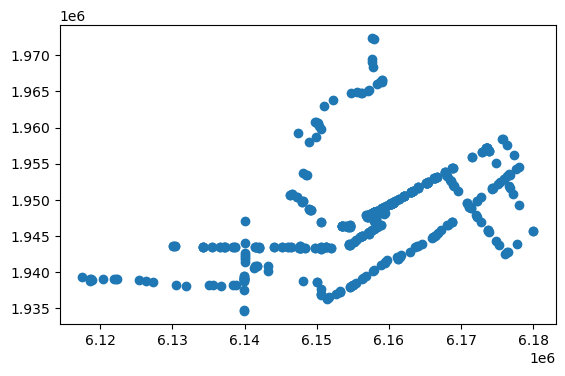

In [24]:
selected_sj_adt.plot()

In [ ]:
#average daily traffic for streets in San Jose that the selected bus routes run along
selected_sj_adt.to_csv("../data/processed/selected_sj_adt.csv")